In [33]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pickle
import os 



# Plot

In [34]:
# ! cp -r ~/adipose_ln/atac/res/VIB_10xmultiome_2_OG/cluster_barcodes/ ~/adipose_ln/atac/res/VIB_10xmultiome_2_WS3000/.

In [35]:
precision=1e-10

fig_res_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_RES'

In [37]:
# ws = 2000000
# ws = 1000000
# ws = 100000
ws = 50000  # Might be too big
# ws = 30000  # might be too big
# ws = 10000
# ws=5000
# ws = 3000
# ws=500
# ws=300

output_dir = f'/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS{ws}'
chromosome = 'chr1'

crbarcode_file = os.path.join(output_dir, '/outs/filtered_peak_bc_matrix/barcodes.tsv')

frag_overlap_subdir = os.path.join(output_dir, 'fragments_overlap_peaks')

entropy_cutoff_file = os.path.join(output_dir, 'entropy_cutoff.csv')


In [38]:
tn5_inser_freq_file = os.path.join(output_dir, f'{chromosome}_insert_frequency.pickle')

with open(tn5_inser_freq_file, 'rb') as f:
    tn5_insert_freq = pickle.load(f)

In [39]:
entropy_file = os.path.join(output_dir, f'{chromosome}_barcode_entropy.pickle')

with open(entropy_file, 'rb') as f:
    entropy_dict = pickle.load(f)
    
    
entropy = np.array(list(entropy_dict.values()))
entropy.sort() # sort the entropy values


bc_entropy = pd.DataFrame.from_dict(entropy_dict, orient='index', columns=['entropy'])


with open(entropy_cutoff_file, 'r') as f:
    entropy_cutoff = float(f.readline().strip().split(',')[1])

In [40]:
summary_statistics_frag_overlap_entropypeaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                          'summary_statistics_frag_overlap_entropypeaks.csv'), sep='\t', 
                                                              index_col=0)
summary_statistics_frag_overlap_entropypeaks_df.index.name = None

summary_statistics_frag_overlap_peaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                 'summary_statistics_frag_overlap_peaks.csv'), sep='\t', 
                                                     index_col=0)
summary_statistics_frag_overlap_peaks_df.index.name = None

In [41]:
entropy_df = summary_statistics_frag_overlap_entropypeaks_df.join(summary_statistics_frag_overlap_peaks_df,
                                                                  lsuffix='_entropypeaks', rsuffix='_peaks')

entropy_df = entropy_df.join(bc_entropy, how='outer')

In [42]:
def calculate_moment(tn5_inser_array:np.ndarray, return_freq:bool=False, print_debug:bool=False):
    cur, freq = np.unique(tn5_inser_array, return_counts=True)
    if print_debug:
        print(cur, freq)
    if cur[0] < precision:
        freq_none = freq[1:]
        cur_none = cur[1:]
    else:
        freq_none = freq
        cur_none = cur

    Mtotal = freq.sum() 
    M1 = freq_none.sum()
    
    non0_p = freq_none / np.sum(freq_none)
    non0_mean = np.sum(cur_none * non0_p)
    non0_2ndorder_moment = np.sum( cur_none**2 * non0_p)
    
    P0 = 1 - (non0_2ndorder_moment - non0_mean) / non0_mean**2

    if return_freq:
        return Mtotal, M1, non0_mean, non0_2ndorder_moment, P0, cur_none, freq_none
    
    return Mtotal, M1, non0_mean, non0_2ndorder_moment, P0


def calculate_moment_fix(tn5_inser_array:np.ndarray, return_freq:bool=False, print_debug:bool=False):
    cur, freq = np.unique(tn5_inser_array, return_counts=True)
    if print_debug:
        print(cur, freq)
    if cur[0] < precision:
        freq_none = freq[1:]
        cur_none = cur[1:]
    else:
        freq_none = freq
        cur_none = cur

    cur_none = (cur_none + 1) // 2 # adjust for paired-end sequencing
    
    Mtotal = freq.sum() 
    M1 = freq_none.sum()
    
    non0_p = freq_none / np.sum(freq_none)
    non0_mean = np.sum(cur_none * non0_p)
    non0_2ndorder_moment = np.sum( cur_none**2 * non0_p)
    
    P0 = 1 - (non0_2ndorder_moment - non0_mean) / non0_mean**2

    if return_freq:
        return Mtotal, M1, non0_mean, non0_2ndorder_moment, P0, cur_none, freq_none

    return Mtotal, M1, non0_mean, non0_2ndorder_moment, P0

In [ ]:
# calcualte entropy without 0-insertion windows 
def calculate_entropy(tn5_insertion_array:np.ndarray):
    # tn5_insert_freq[bc].toarray()
    Mtotal, M1, non0_mean, non0_2ndorder_moment, p0_open_region, cur_none, freq_none = calculate_moment(tn5_insertion_array, return_freq=True)

    if p0_open_region < 0 or p0_open_region >= 1:
        Nwindows_0inser_open_region = None
    else:
        Nwindows_0inser_open_region = np.floor(p0_open_region / (1 - p0_open_region) * M1)

        Nwindows_0inser_open_region = np.max((Nwindows_0inser_open_region, Mtotal - M1))

    if Nwindows_0inser_open_region is None:
        Entropy_final = None
    else:
        Nwindows_closed_region = int(Mtotal - M1 - Nwindows_0inser_open_region)
        total_freq = np.concatenate(([Nwindows_closed_region, Nwindows_0inser_open_region], freq_none))

        # calculate entropy
        posi_freq = total_freq[total_freq > 0]
        p_final = posi_freq / posi_freq.sum()
        Entropy_final = -np.sum(p_final * np.log2(p_final))
    return Entropy_final


## Calcualte multiple entropies: entropy of mixture distribution, entropy of open region, entropy of final distribution
def calcualte_multiple_entropies(tn5_insert_array:np.ndarray, return_all_paras:bool=False):
    Mtotal, M1, non0_mean, non0_2ndorder_moment, p0_open_region, cur_none, freq_none = calculate_moment_fix(tn5_insert_array, return_freq=True)

    if p0_open_region <= 0 or p0_open_region >= 1:
        Nwindows_0inser_open_region = None
        Entropy_mixturedist = None
        Entropy_open_region = None
        Entropy_final = None
    else:
        Nwindows_0inser_open_region = np.floor(M1 / ( 1- p0_open_region) * p0_open_region )
        Nwindows_0inser_open_region = np.min((Nwindows_0inser_open_region, Mtotal - M1))
        Nwindows_closed_region = int(Mtotal - M1 - Nwindows_0inser_open_region)

        total_freq = np.concatenate(([Nwindows_closed_region, Nwindows_0inser_open_region], freq_none))

        # calculate entropy of mix states
        p_stats = np.array([Nwindows_closed_region, Mtotal - Nwindows_closed_region]) / Mtotal
        Entropy_state = -np.sum(p_stats * np.log2(p_stats))

        open_region_freq = total_freq[1:]
        open_region_freq_non0 = open_region_freq[open_region_freq > 0]
        open_region_p = open_region_freq_non0 / open_region_freq_non0.sum()

        # calculate entropy as a mixture distribution 
        Entropy_open_region = -np.sum(open_region_p * np.log2(open_region_p))
        Entropy_mixturedist = Entropy_state + (1 - Nwindows_closed_region / Mtotal) * Entropy_open_region

        # calculate entropy of final distribution -- Simply breaking down 0-freq to from open and closed regions
        posi_freq = total_freq[total_freq > 0]
        p_final = posi_freq / posi_freq.sum()
        Entropy_final = -np.sum(p_final * np.log2(p_final))

    if not return_all_paras:
        return Entropy_mixturedist, Entropy_open_region, Entropy_final
    
    other_paras = (non0_mean, non0_2ndorder_moment, p0_open_region)
    return Entropy_mixturedist, Entropy_open_region, Entropy_final, other_paras


def break_down_freq(tn5_insert_array:np.ndarray):
    cur, freq = np.unique(tn5_insert_array, return_counts=True)
    if cur[0] == 0:
        freq_none = freq[1:]
        cur_none = cur[1:]
    else:
        freq_none = freq
        cur_none = cur

    Mtotal = freq.sum() 
    M1 = freq_none.sum()
    
    non0_p = freq_none / np.sum(freq_none)
    non0_mean = np.sum(cur_none * non0_p)
    non0_2ndorder_moment = np.sum( cur_none**2 * non0_p)


    p0_open_region = 1 - (non0_2ndorder_moment - non0_mean) / non0_mean**2

    if p0_open_region < 0 or p0_open_region >= 1:
        Nwindows_0inser_open_region = None
    else:
        Nwindows_0inser_open_region = np.floor(p0_open_region / (1 - p0_open_region) * M1)
        Nwindows_0inser_open_region = np.max((Nwindows_0inser_open_region, Mtotal - M1))

    if Nwindows_0inser_open_region is None:
        total_freq = np.concatenate(([None, None], freq_none))
    else:
        Nwindows_closed_region = int(Mtotal - M1 - Nwindows_0inser_open_region)
        total_freq = np.concatenate(([Nwindows_closed_region, Nwindows_0inser_open_region], freq_none))
    
    total_cur = np.concatenate(([-1, 0], cur_none))

    return total_cur, total_freq

# # adjust for paired-end sequencing
# for bc in tn5_insert_freq.keys():
#     if bc not in entropy_df.index:
#         continue
#     else:
#         _, _, non0_mean, non0_2ndorder_moment, p0= calculate_moment_fix(tn5_insert_freq[bc].toarray())

#         entropy_df.loc[bc, 'non0_mean_fix'] = non0_mean
#         entropy_df.loc[bc, 'non0_2ndorder_moment_fix'] = non0_2ndorder_moment
#         entropy_df.loc[bc, 'P0_fix'] = p0

# entropy_df['1-P0_fix'] =  1- entropy_df['P0_fix']


# for bc in tn5_insert_freq.keys():
#     if bc not in entropy_df.index:
#         continue
#     else:
#         Mtotal, M1, non0_mean, non0_2ndorder_moment, p0= calculate_moment(tn5_insert_freq[bc].toarray())
#         entropy_df.loc[bc, 'Mtotal'] = Mtotal
#         entropy_df.loc[bc, 'M1'] = M1
#         entropy_df.loc[bc, 'non0_mean'] = non0_mean
#         entropy_df.loc[bc, 'non0_2ndorder_moment'] = non0_2ndorder_moment
#         entropy_df.loc[bc, 'P0'] = p0
        
# entropy_df['1-P0'] =  1- entropy_df['P0']

In [ ]:
# calcualte entropy without 0-insertion windows 
for bc in tn5_insert_freq.keys():
    if bc not in entropy_df.index:
        continue
    else:
        Entropy_mixturedist, Entropy_open_region, Entropy_final, other_paras = calcualte_multiple_entropies(tn5_insert_freq[bc].toarray(), return_all_paras=True)
        entropy_df.loc[bc, 'entropy_mixdist_c'] = Entropy_mixturedist
        entropy_df.loc[bc, 'entropy_open_region'] = Entropy_open_region
        entropy_df.loc[bc, 'entropy_final'] = Entropy_final
        entropy_df.loc[bc, 'non0_mean'] = other_paras[0]
        entropy_df.loc[bc, 'non0_2ndorder_moment'] = other_paras[1]
        entropy_df.loc[bc, 'P0_open_region'] = other_paras[2]
    
entropy_df[ '1-P0'] = 1- entropy_df['P0_open_region']

# # adjust for paired-end sequencing
# for bc in tn5_insert_freq.keys():
#     if bc not in entropy_df.index:
#         continue
#     else:
#         _, _, non0_mean, non0_2ndorder_moment, p0= calculate_moment_fix(tn5_insert_freq[bc].toarray())

#         entropy_df.loc[bc, 'non0_mean_fix'] = non0_mean
#         entropy_df.loc[bc, 'non0_2ndorder_moment_fix'] = non0_2ndorder_moment
#         entropy_df.loc[bc, 'P0_fix'] = p0

# entropy_df['1-P0_fix'] =  1- entropy_df['P0_fix']


# for bc in tn5_insert_freq.keys():
#     if bc not in entropy_df.index:
#         continue
#     else:
#         Mtotal, M1, non0_mean, non0_2ndorder_moment, p0= calculate_moment(tn5_insert_freq[bc].toarray())
#         entropy_df.loc[bc, 'Mtotal'] = Mtotal
#         entropy_df.loc[bc, 'M1'] = M1
#         entropy_df.loc[bc, 'non0_mean'] = non0_mean
#         entropy_df.loc[bc, 'non0_2ndorder_moment'] = non0_2ndorder_moment
#         entropy_df.loc[bc, 'P0'] = p0
        
# entropy_df['1-P0'] =  1- entropy_df['P0']

/tmp/ipykernel_686257/2219007005.py:44: RuntimeWarning: divide by zero encountered in log2
  Entropy_state = -np.sum(p_stats * np.log2(p_stats))
/tmp/ipykernel_686257/2219007005.py:44: RuntimeWarning: invalid value encountered in multiply
  Entropy_state = -np.sum(p_stats * np.log2(p_stats))
/tmp/ipykernel_686257/2219007005.py:44: RuntimeWarning: divide by zero encountered in log2
  Entropy_state = -np.sum(p_stats * np.log2(p_stats))
/tmp/ipykernel_686257/2219007005.py:44: RuntimeWarning: invalid value encountered in multiply
  Entropy_state = -np.sum(p_stats * np.log2(p_stats))
/tmp/ipykernel_686257/2219007005.py:44: RuntimeWarning: divide by zero encountered in log2
  Entropy_state = -np.sum(p_stats * np.log2(p_stats))
/tmp/ipykernel_686257/2219007005.py:44: RuntimeWarning: invalid value encountered in multiply
  Entropy_state = -np.sum(p_stats * np.log2(p_stats))


In [46]:
entropy_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy,entropy_mixdist_c,entropy_open_region,entropy_final,non0_mean,non0_2ndorder_moment,P0_open_region
AAACAAGCAAACATGT-1,4,1.0,25.000000,4,1.0,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACAAGCAAACCAGC-1,1,1.0,100.000000,1,1.0,100.000000,0.002756,NaN,NaN,NaN,1.000000,1.000000,1.000000
AAACAAGCAAACCTAG-1,207,16.0,7.729469,207,16.0,7.729469,0.032447,NaN,NaN,NaN,2.071429,7.928571,-0.365042
AAACAAGCAAACTAAC-1,1,0.0,0.000000,1,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACAAGCAAAGAAGC-1,987,43.0,4.356636,987,43.0,4.356636,0.049886,NaN,NaN,NaN,8.100000,149.500000,-1.155159


## Load CR's barcodes info 

In [47]:
cr_clustering_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/analysis/clustering/graphclust/clusters.csv'

cr_clustering_df = pd.read_csv(cr_clustering_file, sep=',', index_col=0)

In [48]:
all_df = entropy_df.join(cr_clustering_df, how='outer')
all_df['log(total_fragments)'] = np.log10(all_df['total_fragments_entropypeaks'] + precision)
all_df['log(entropy)'] = np.log10(all_df['entropy'] + precision)
# Create a binary column indicating whether a barcode is a cell by CR's cell calling
all_df['cr_bc'] = ~all_df['Cluster'].isna()

In [49]:
all_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy,entropy_mixdist_c,entropy_open_region,entropy_final,non0_mean,non0_2ndorder_moment,P0_open_region,Cluster,log(total_fragments),log(entropy),cr_bc
AAACAAGCAAACATGT-1,4,1.0,25.000000,4,1.0,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.020600e-01,NaN,False
AAACAAGCAAACCAGC-1,1,1.0,100.000000,1,1.0,100.000000,0.002756,NaN,NaN,NaN,1.000000,1.000000,1.000000,NaN,4.342945e-11,-2.559733,False
AAACAAGCAAACCTAG-1,207,16.0,7.729469,207,16.0,7.729469,0.032447,NaN,NaN,NaN,2.071429,7.928571,-0.365042,NaN,2.315970e+00,-1.488823,False
AAACAAGCAAACTAAC-1,1,0.0,0.000000,1,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.342945e-11,NaN,False
AAACAAGCAAAGAAGC-1,987,43.0,4.356636,987,43.0,4.356636,0.049886,NaN,NaN,NaN,8.100000,149.500000,-1.155159,NaN,2.994317e+00,-1.302017,False


# Plot ratio (estimate of (1-P0)/ P0)

In [55]:
neg_df = all_df[all_df['P0_open_region'] < 0 ]
neg_df_2 = neg_df[neg_df['log(total_fragments)'] > 3.3]

In [56]:
calculate_moment(tn5_insert_freq[neg_df_2.index[0]].toarray())

(4980, 1917, 7.786124152321336, 116.86280646844027, -0.7992407189057509)

In [57]:
calculate_moment_fix(tn5_insert_freq[neg_df_2.index[10]].toarray())

(4980, 509, 1.6856581532416504, 6.2907662082514735, -0.6206932150988094)

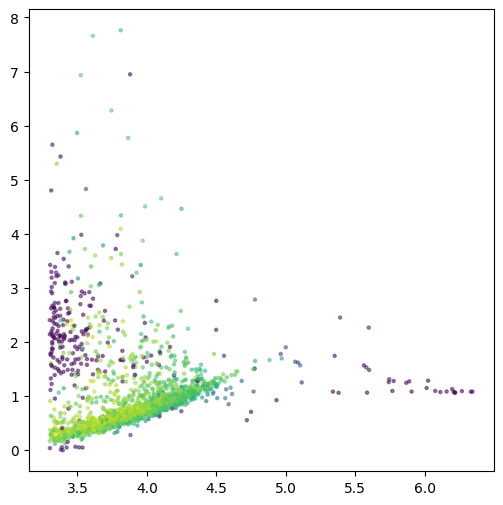

In [60]:
a_df = all_df[all_df['log(total_fragments)'] > 3.3]

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(  a_df['log(total_fragments)'],  1 - a_df['P0_open_region'] ,
           c = a_df['frag_overlap_entropy_peaks%'],
           s=5, alpha=0.5)

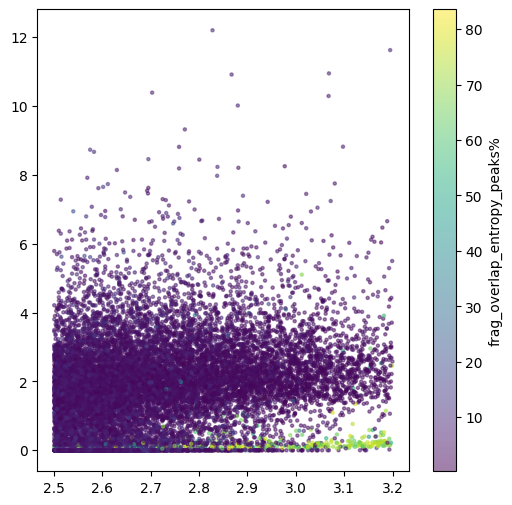

In [62]:
a_df = all_df[(all_df['log(total_fragments)'] > 2.5) & (all_df['log(total_fragments)'] < 3.2)]

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter( a_df['log(total_fragments)'], 
              1 - a_df['P0_open_region'], c= a_df['frag_overlap_entropy_peaks%'], s=5, alpha=0.5)
fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')

In [71]:
a_df['non0_2ndorder_moment'].describe()

count    1882.000000
mean        2.507609
std         1.267735
min         1.031579
25%         1.353710
50%         2.238247
75%         3.368604
max         6.999420
Name: non0_2ndorder_moment, dtype: float64

## Plot Mixture Entropy

In [ ]:
## see different entropy calculation

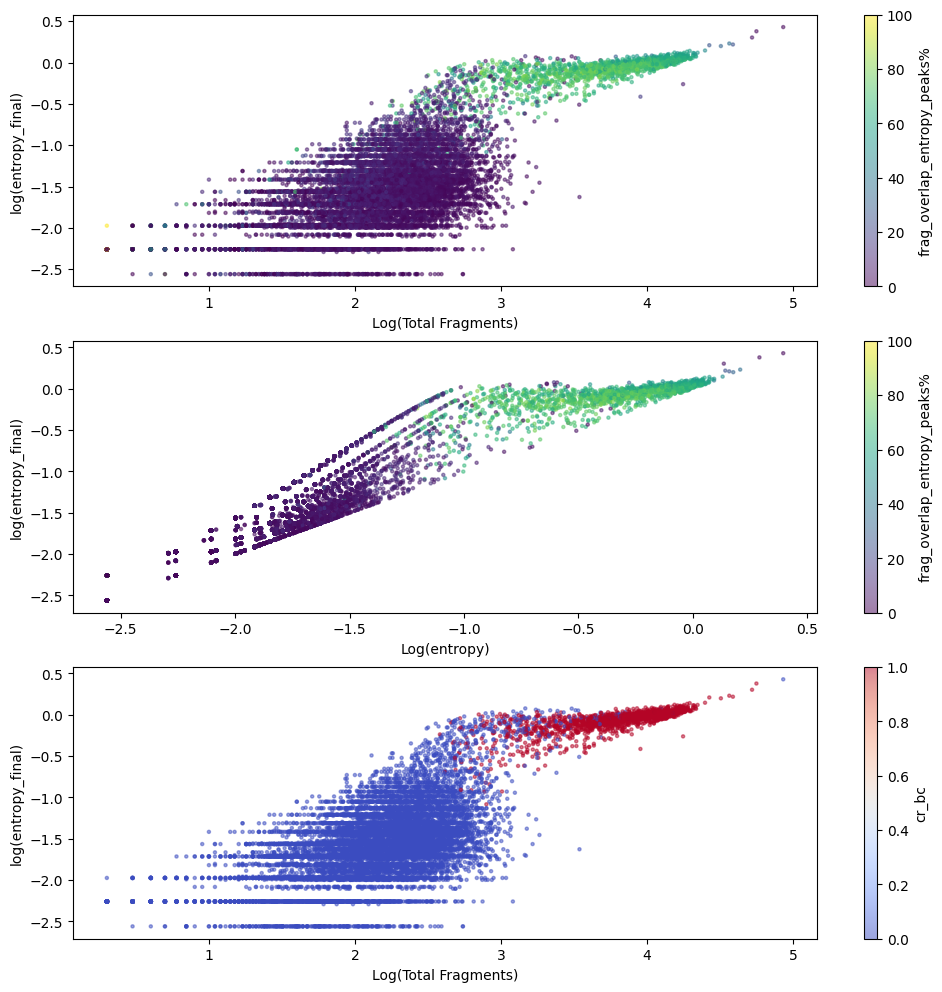

In [63]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_final']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_final)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter(all_df['log(entropy)'], np.log10(all_df['entropy_final']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_final)')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_final']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_final)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')


In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter(all_df['log(entropy)'], np.log10(all_df['entropy_mixdist_c']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_open_region']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_open_region)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter(all_df['log(entropy)'], np.log10(all_df['entropy_open_region']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_open_region)')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_open_region']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_open_region)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')

# And what

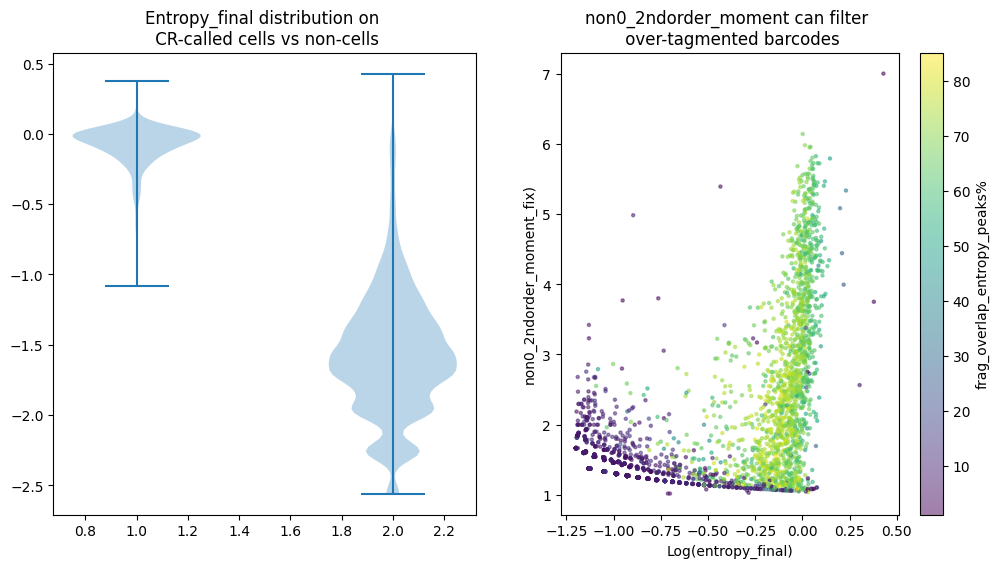

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(12 ,6))
ax = ax.flatten()
ax[0].violinplot([np.log10(all_df.loc[all_df['cr_bc'], 'entropy_final'].dropna()+ precision) ,
                          np.log10(all_df.loc[~all_df['cr_bc'], 'entropy_final'].dropna()+ precision)],
               showmeans=False)
ax[0].set_title('Entropy_final distribution on \n CR-called cells vs non-cells')

a_df =  all_df[all_df['entropy_final'] > 10 **(-1.2)]
ax[1].scatter(  np.log10(a_df['entropy_final']), a_df['non0_2ndorder_moment'],  c=a_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy_final)')
ax[1].set_ylabel('non0_2ndorder_moment_fix)')
ax[1].set_title('non0_2ndorder_moment can filter \n over-tagmented barcodes')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')

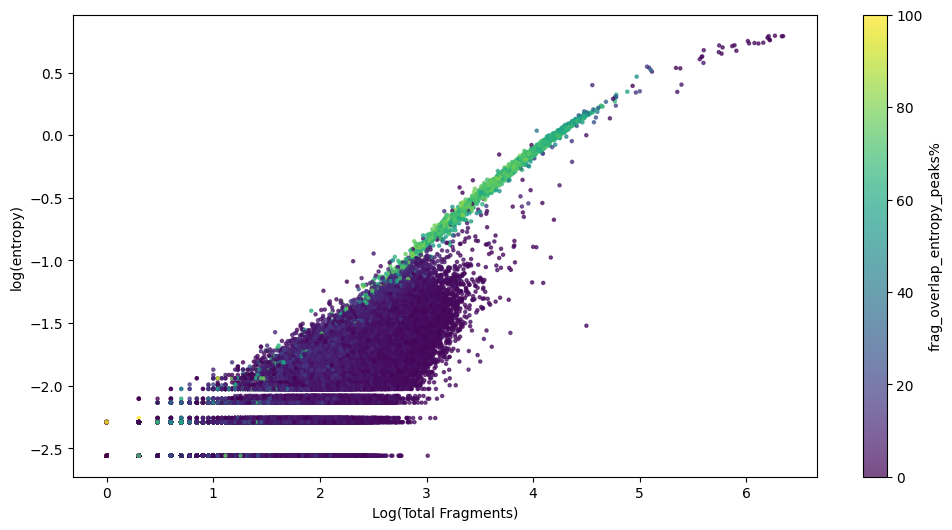

In [80]:
fig, ax = plt.subplots(figsize=(12,6))

ax.scatter( all_df['log(total_fragments)'], all_df['log(entropy)'], c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.7, s=5, cmap='viridis')
ax.set_xlabel('Log(Total Fragments)')
ax.set_ylabel('log(entropy)')
fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')

In [81]:
all_df['entropy_pass'] = (all_df['entropy_final'] > 10 ** (-0.7)) & (all_df['non0_2ndorder_moment'] > 1.05)


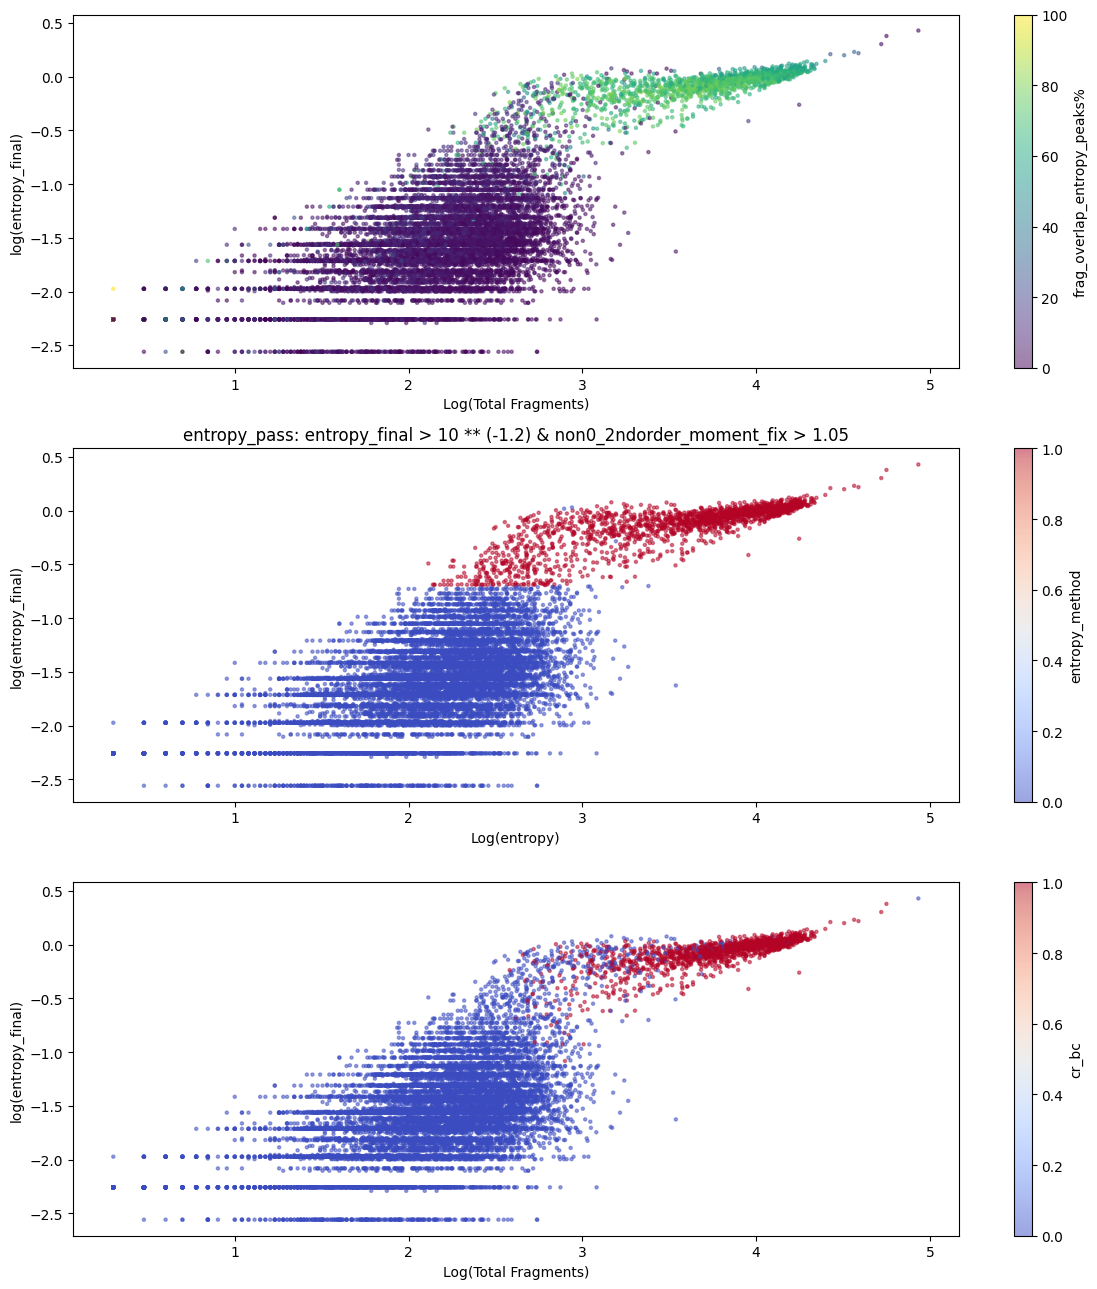

In [84]:
fig, ax = plt.subplots(3, 1, figsize=(12,13))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_final']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_final)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_final']),  c=all_df['entropy_pass'], 
           alpha=0.5, s=5, cmap='coolwarm')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_final)')
ax[1].set_title('entropy_pass: entropy_final > 10 ** (-1.2) & non0_2ndorder_moment_fix > 1.05')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='entropy_method')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_final']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_final)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')

fig.tight_layout()

## Top 20k as pre-filter 

In [ ]:
top20k_df = all_df.sort_values(by='total_fragments_entropypeaks', ascending=False).head(20000)

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
_ = ax.hist(np.log10(top20k_df['entropy_final']), bins=100)

In [ ]:
all_df['cr_bc'].value_counts()

In [ ]:
all_df[all_df['entropy_final'] > 10**(-1.5)].shape

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(np.arange(20000), np.log10(top20k_df['entropy_final'].sort_values(ascending=False) + precision), s=10)
ax.set_ylabel('log(entropy_final)')
ax.set_xlabel('Ranked Barcodes (by entropy_final)')

In [ ]:
fig,ax = plt.subplots(figsize=(6,6))
_ = ax.hist(np.log10(all_df['entropy_final']+ precision), bins=100)

In [ ]:


special_bc = 'GACAGGCTCGAGGAGG-1'  # bad-quality cell -- probably over-tagmented 

fig, ax = plt.subplots( figsize=(12,12))
ax.scatter( top20k_df['log(total_fragments)'], np.log10(top20k_df['entropy_final']), c=top20k_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax.set_xlabel('Log(Total Fragments)')
ax.set_ylabel('log(entropy_mixdist)')
ax.scatter(top20k_df.loc[special_bc, 'log(total_fragments)'], np.log10(top20k_df.loc[special_bc, 'entropy_final']+ precision),
              color='red', s=50, label='special_bc')
ax.legend()


fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')


# See Tn5 Insertions

## Set 1

In [ ]:
subset_df = all_df[(all_df['entropy_final'] < 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3)]

good_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] > 4)]

crazy_df = all_df[(all_df['entropy_final'] > 10 ** (-0.5)) & (all_df['log(total_fragments)'] > 4)]

fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 75, 78

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_final']

        val, freq = np.unique(tn5_insert_freq[sample_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])     
        ax[0, 0].plot(val[1:], freq[1:], marker='o', 
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_final']

        val, freq = np.unique(tn5_insert_freq[good_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[1, 0].plot(val[1:], freq[1:], marker='o',
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_final']
        val, freq = np.unique(tn5_insert_freq[crz_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[2, 0].plot(val[1:], freq[1   :], marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()

In [ ]:
subset_df = all_df[(all_df['entropy_final'] < 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3)]

good_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] > 4)]

crazy_df = all_df[(all_df['entropy_final'] > 10 ** (-0.5)) & (all_df['log(total_fragments)'] > 4)]

fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 75, 78

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_final']

        val, freq = break_down_freq(tn5_insert_freq[sample_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq)     

        ax[0, 0].plot(val[freq > 0], p_non0[freq > 0], marker='o', 
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val[freq > 0], p_non0[freq > 0], marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[2:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_final']

        val, freq = break_down_freq(tn5_insert_freq[good_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq) 
        ax[1, 0].plot(val[freq > 0], p_non0[freq > 0], marker='o',
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val[freq > 0], p_non0[freq > 0], marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[2:].sum()}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_final']
        val, freq = break_down_freq(tn5_insert_freq[crz_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq) 
        ax[2, 0].plot(val[freq > 0], p_non0[freq > 0], marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val[freq > 0], p_non0[freq > 0], marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[2:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()

## Set 2

In [ ]:
bad_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] < 30) ]

good_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] > 50) ]

crazy_df = all_df[(all_df['log(total_fragments)'] >  3) &  (all_df['frag_overlap_entropy_peaks%'] < 30) ]


fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = bad_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 75, 78

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_final']

        val, freq = np.unique(tn5_insert_freq[sample_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])     
        ax[0, 0].plot(val[1:], freq[1:], marker='o', 
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_final']

        val, freq = np.unique(tn5_insert_freq[good_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[1, 0].plot(val[1:], freq[1:], marker='o',
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_final']
        val, freq = np.unique(tn5_insert_freq[crz_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[2, 0].plot(val[1:], freq[1   :], marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()

In [ ]:
bad_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] < 30) ]

good_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] > 50) ]

crazy_df = all_df[(all_df['log(total_fragments)'] >  3) &  (all_df['frag_overlap_entropy_peaks%'] < 30) ]


fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 75, 78

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_final']

        val, freq = break_down_freq(tn5_insert_freq[sample_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq)     
        ax[0, 0].plot(val, freq, marker='o', 
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_final']

        val, freq = break_down_freq(tn5_insert_freq[good_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq) 
        ax[1, 0].plot(val, freq, marker='o',
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_final']
        val, freq = break_down_freq(tn5_insert_freq[crz_bc[0]].toarray())

        val = val[freq != None]
        freq = freq[freq != None]
        p_non0 = freq/  np.sum(freq) 
        ax[2, 0].plot(val, freq, marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()

# Plot entropy of mixture distribution

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter(all_df['log(entropy)'], np.log10(all_df['entropy_mixdist']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')